In [1]:
pip install pandas

Note: you may need to restart the kernel to use updated packages.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
print("All libraries working ")

All libraries working 


In [3]:
!pip install matplotlib

In [4]:
!pip install seaborn
!pip install sklearn

  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-

In [5]:

import pandas as pd

train = pd.read_csv("../data/train.csv")
store = pd.read_csv("../data/store.csv")

print("Train Shape:", train.shape)
print("Store Shape:", store.shape)

Train Shape: (1017209, 9)
Store Shape: (1115, 10)


C:\Users\SHREE\AppData\Local\Temp\ipykernel_15476\418695525.py:3: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [6]:
train = pd.read_csv("../data/train.csv", low_memory=False)

In [143]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

In [8]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [9]:
train = pd.read_csv(
    r"d:\Rossmann_Sales_Forecasting\data\train.csv",
    low_memory=False
)

store = pd.read_csv(
    r"d:\Rossmann_Sales_Forecasting\data\store.csv"
)

print(train.shape)
print(store.shape)

(1017209, 9)
(1115, 10)


# Logging

In [10]:
import logging

In [11]:
logging.info("Data loaded successfully")
logging.info("EDA started")
logging.info("Promotion analysis completed")

# Correlation Between Customers and Sales

## Observation

The correlation coefficient between Customers and Sales is:

**0.8947**

## Business Insights

- There is a very strong positive relationship between customer count and sales.
- Stores with higher customer traffic generally achieve higher revenue.
- Customer footfall is a key driver of sales performance.
- Strategies aimed at increasing customer visits can significantly improve sales.

## Conclusion

Customer count is one of the strongest predictors of sales and should be considered a critical feature in the sales forecasting model.

# Data Preview

Data Understanding

In this section, we explore the structure of the datasets.

In [12]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [13]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [14]:
store.isnull().sum()

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64

In [15]:
train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [16]:
train["Sales"].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

 # Feature Engineering




Convert Date column into useful features.

In [17]:
train["Date"] = pd.to_datetime(train["Date"])

train["Year"] = train["Date"].dt.year
train["Month"] = train["Date"].dt.month
train["Day"] = train["Date"].dt.day
train["Weekday"] = train["Date"].dt.dayofweek

train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,Month,Day,Weekday
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,7,31,4
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,7,31,4
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,7,31,4
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,7,31,4
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,7,31,4


Insight:-
The original Date column was transformed into:
Year
Month
Day
Weekday
Business Insight :-
These features help capture seasonal sales patterns.
Weekly and monthly trends can reveal customer purchasing behavior.
Holiday seasons and weekends may have a significant impact on sales.

# Merge Dataset

Merge Train and Store Dataset

In [18]:
df = pd.merge(train, store, on="Store", how="left")
print(df.shape)

(1017209, 22)



Insight:-
The sales dataset was successfully merged with the store dataset using the Store ID.
The merged dataset combines transactional sales information with store characteristics.
Business Insight:-
Enriched datasets generally improve model performance because they provide more context about each store.
Store attributes, competition, and promotional information can help explain variations in sales.

head after merging

In [19]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Year,...,Weekday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,2015,...,4,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,2015,...,4,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,2015,...,4,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,2015,...,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,2015,...,4,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


missing value after merging


In [20]:
df.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Year                              0
Month                             0
Day                               0
Weekday                           0
StoreType                         0
Assortment                        0
CompetitionDistance            2642
CompetitionOpenSinceMonth    323348
CompetitionOpenSinceYear     323348
Promo2                            0
Promo2SinceWeek              508031
Promo2SinceYear              508031
PromoInterval                508031
dtype: int64

# Exploratory Data Analysis (EDA)

In [21]:
import matplotlib.pyplot as plt

plt.style.use("ggplot")

1. Sales Distribution Histogram

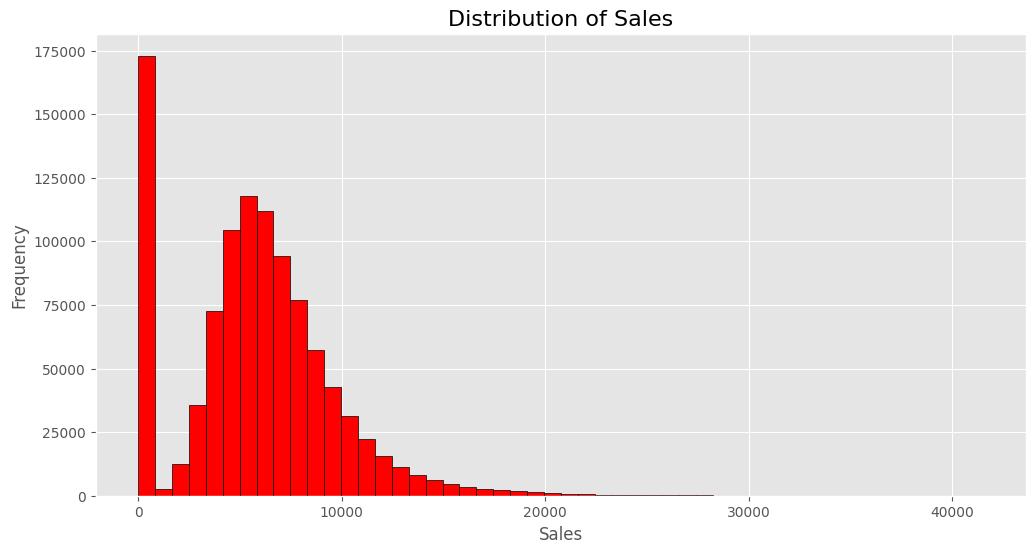

In [22]:
plt.figure(figsize=(12,6))

plt.hist(df["Sales"], bins=50,
         color="red",
         edgecolor="black")

plt.title("Distribution of Sales", fontsize=16)
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

Insight
Sales distribution is positively skewed.
Most stores generate low to moderate sales.
A few stores generate exceptionally high sales.

2. Promotion Impact

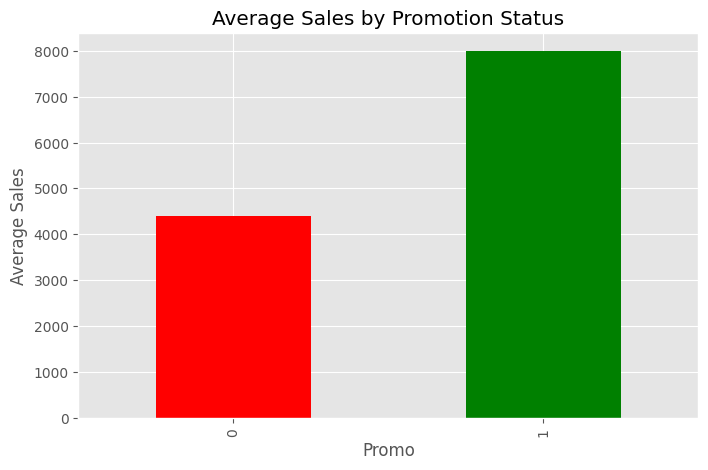

In [23]:
promo_sales = df.groupby("Promo")["Sales"].mean()

plt.figure(figsize=(8,5))

promo_sales.plot(
    kind="bar",
    color=["red", "green"]
)

plt.title("Average Sales by Promotion Status")
plt.xlabel("Promo")
plt.ylabel("Average Sales")

plt.show()


red colour - no promotion
green colour - promotion Active

3. Open vs Closed Stores

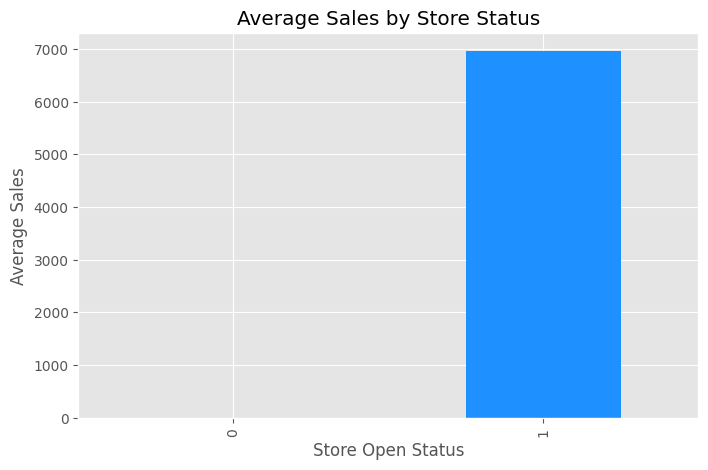

In [24]:
open_sales = df.groupby("Open")["Sales"].mean()

plt.figure(figsize=(8,5))

open_sales.plot(
    kind="bar",
    color=["pink", "dodgerblue"]
)

plt.title("Average Sales by Store Status")
plt.xlabel("Store Open Status")
plt.ylabel("Average Sales")

plt.show()

4. Monthly Sales Trend

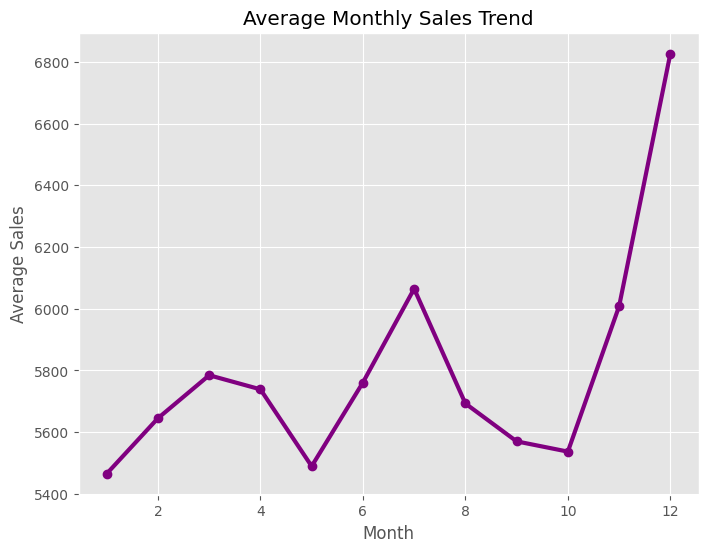

In [25]:
monthly_sales = df.groupby("Month")["Sales"].mean()

plt.figure(figsize=(8,6))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=3,
    color="purple"
)

plt.title("Average Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Sales")

plt.grid(True)

plt.show()

5. Store Type Analysis

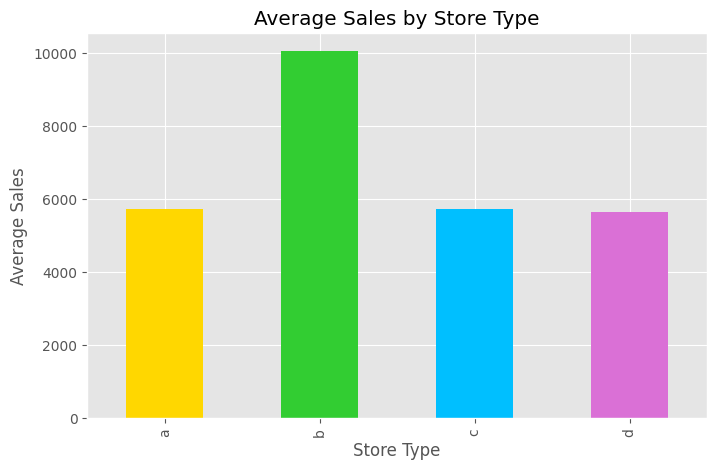

In [26]:
store_type_sales = df.groupby("StoreType")["Sales"].mean()

plt.figure(figsize=(8,5))

store_type_sales.plot(
    kind="bar",
    color=["gold", "limegreen", "deepskyblue", "orchid"]
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

customers vs Sales

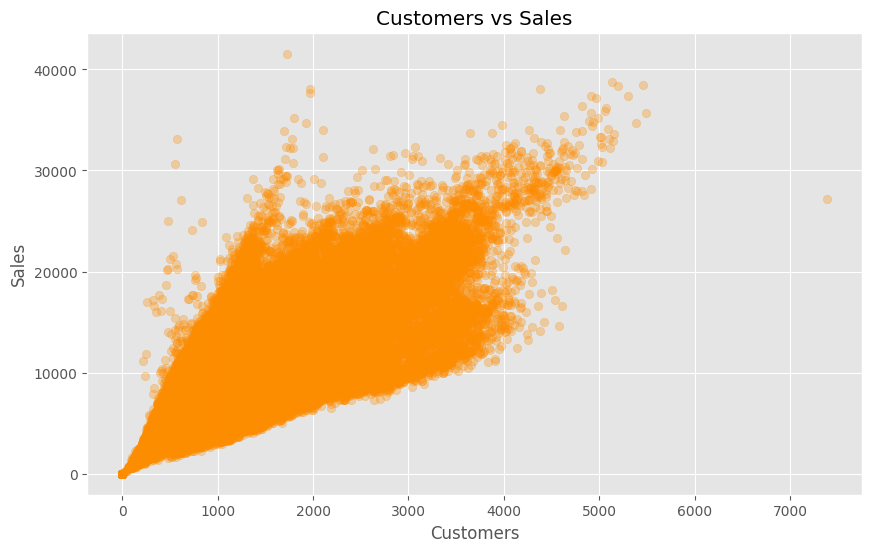

In [27]:
plt.figure(figsize=(10,6))

plt.scatter(
    df["Customers"],
    df["Sales"],
    alpha=0.3,
    color="darkorange"
)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")

plt.show()

Insight
Higher customer counts should correspond to higher sales.
Strong positive correlation is expected.

Sales before, during and after holidays

In [28]:
holiday_sales = df.groupby("StateHoliday")["Sales"].mean()

holiday_sales

StateHoliday
0    5947.483893
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64

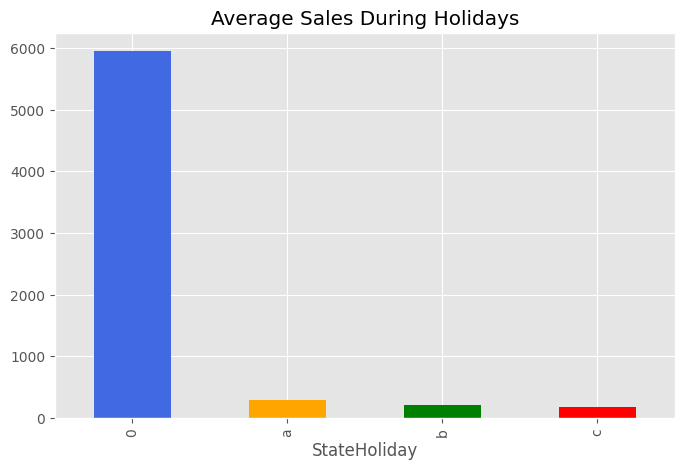

In [29]:
holiday_sales.plot(
    kind="bar",
    figsize=(8,5),
    color=["royalblue","orange","green","red"]
)

plt.title("Average Sales During Holidays")
plt.show()

In [30]:
promo_sales = df.groupby("Promo")["Sales"].mean()
print(promo_sales)

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [31]:
store_type_sales = df.groupby("StoreType")["Sales"].mean()

print(store_type_sales)

StoreType
a     5738.179710
b    10058.837334
c     5723.629246
d     5641.819243
Name: Sales, dtype: float64


Store Type B Performs Best

Store Type B has the highest average sales:

Type B: 10,059
Type A: 5,738
Type C: 5,724
Type D: 5,642

Store Type B generates nearly twice the sales of other store types.

In [32]:
weekday_sales = df.groupby("Weekday")["Sales"].mean()

print(weekday_sales)

Weekday
0    7809.044510
1    7005.244467
2    6555.884138
3    6247.575913
4    6723.274305
5    5847.562599
6     204.183189
Name: Sales, dtype: float64


# Task 2.1 Preprocessing Pipeline
Preparing data for machine learning models.

 Handle Missing Values
Competition Distance

In [33]:
df["CompetitionDistance"] = df["CompetitionDistance"].fillna(
    df["CompetitionDistance"].median()
)

Competition Open Month

In [34]:
df["CompetitionOpenSinceMonth"] = df[
    "CompetitionOpenSinceMonth"
].fillna(0)

Competition Open Year

In [35]:
df["CompetitionOpenSinceYear"] = df[
    "CompetitionOpenSinceYear"
].fillna(0)

Promo2 Features

In [36]:
df["Promo2SinceWeek"] = df["Promo2SinceWeek"].fillna(0)

df["Promo2SinceYear"] = df["Promo2SinceYear"].fillna(0)

df["PromoInterval"] = df["PromoInterval"].fillna("None")

Weekend Feature

In [37]:
df["IsWeekend"] = df["Weekday"].apply(
    lambda x: 1 if x >= 5 else 0
)

Beginning / Mid / End of Month

In [38]:
def month_period(day):

    if day <= 10:
        return "Beginning"

    elif day <= 20:
        return "Mid"

    else:
        return "End"

df["MonthPeriod"] = df["Day"].apply(month_period)

Start of Month Flag

In [39]:
df["IsMonthStart"] = df["Date"].dt.is_month_start.astype(int)


End of Month Flag

In [40]:
df["IsMonthEnd"] = df["Date"].dt.is_month_end.astype(int)

Encode Categorical Features

StoreType

In [41]:
from sklearn.preprocessing import LabelEncoder

le_store = LabelEncoder()

df["StoreType"] = le_store.fit_transform(
    df["StoreType"]
)

Assortment

In [42]:
le_assort = LabelEncoder()

df["Assortment"] = le_assort.fit_transform(
    df["Assortment"]
)

PromoInterval

In [43]:
le_promo = LabelEncoder()

df["PromoInterval"] = le_promo.fit_transform(
    df["PromoInterval"]
)

StateHoliday


In [44]:
le_holiday = LabelEncoder()

df["StateHoliday"] = le_holiday.fit_transform(
    df["StateHoliday"].astype(str)
)

 Remove Date Column

In [45]:
df = df.drop("Date", axis=1)

Feature and Target Split

In [46]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

Scaling

In [47]:
X.select_dtypes(include="object").columns

Index(['MonthPeriod'], dtype='object')

string columns select

In [48]:
X.select_dtypes(include="string")

""
0
1
2
3
4
...
1017204
1017205
1017206
1017207



object + string

In [49]:
X.select_dtypes(include=["object", "string"])

,MonthPeriod
0,End
1,End
2,End
3,End
4,End
...,...
1017204,Beginning
1017205,Beginning
1017206,Beginning
1017207,Beginning


In [50]:
from sklearn.preprocessing import LabelEncoder

le_month = LabelEncoder()

df["MonthPeriod"] = le_month.fit_transform(df["MonthPeriod"])

In [51]:
print(df.select_dtypes(include="object").columns)

Index([], dtype='object')


create X and scale

In [52]:
X = df.drop("Sales", axis=1)

y = df["Sales"]

In [53]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

Check shape

In [54]:
print(X_scaled.shape)
print(y.shape)

(1017209, 24)
(1017209,)


Machine Learning, building models using Sklearn Pipelines 

RandomForestRegressor

In [55]:
from sklearn.ensemble import RandomForestRegressor

In [56]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(n_estimators=100, random_state=42))
])

Full ML Pipeline (Regression + RandomForest)
1. Imports

In [57]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

2. Split Features & Target

In [58]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

In [59]:
df["MonthPeriod"] = pd.to_datetime(df["MonthPeriod"])
df["Month"] = df["MonthPeriod"].dt.month
df["Year"] = df["MonthPeriod"].dt.year
df.drop("MonthPeriod", axis=1, inplace=True)

3. Identify Column Types

In [60]:
num_cols = X.select_dtypes(include=["int64", "float64"]).columns
cat_cols = X.select_dtypes(include=["object", "string"]).columns

4. Preprocessing Pipelines
Numeric pipeline

In [61]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

Categorical pipeline

In [62]:
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

5. Combine Preprocessing

In [63]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, num_cols),
        ("cat", categorical_transformer, cat_cols)
    ]
)

6. Final Pipeline (Model + Preprocessing)

In [64]:
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", model)
])

7. Train-Test Split

In [65]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [66]:
train = pd.read_csv("../data/train.csv")

C:\Users\SHREE\AppData\Local\Temp\ipykernel_15476\1501820121.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")


In [67]:
train = pd.read_csv("../data/train.csv", low_memory=False)

There are more than 10 lakh (1 million+) rows.
Using One-Hot Encoding with Random Forest causes RAM to get filled, which leads to crashes or memory issues.

Data sample

In [68]:
df = df.sample(200000, random_state=42)

Only important columns select

In [69]:
cols = [
    "Store",
    "DayOfWeek",
    "Promo",
    "StateHoliday",
    "SchoolHoliday",
    "Year",
    "Month",
    "Day",
    "Weekday",
    "Customers"
]

X = df[cols]
y = df["Sales"]

Remove leakage

In [70]:
X = df.drop(["Sales"], axis=1)
y = df["Sales"]

Model simplify

In [71]:
model = RandomForestRegressor(
    n_estimators=50,   
    max_depth=10,      
    random_state=42,
    n_jobs=-1
)

In [72]:
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_

prediction

In [73]:
y_pred = model.predict(X_test)

Evaluate 

In [74]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 619.1952963701525
RMSE: 931.4586203250166
R2 Score: 0.9413329420939934


MAE (Mean Absolute Error)

 “On average, our model is off by X sales units.”

Example:
MAE = 1200
  Model prediction is wrong by ~1200 sales units on average
 -RMSE

 “Penalizes large errors more”

Example:
RMSE = 1800
 Some predictions have large deviations
 R² Score

 model performance

R² = 0.85
 Model explains 85% of variance in sales

# Post Prediction analysis

Feature Importance

In [75]:
%who

ColumnTransformer	 LabelEncoder	 OneHotEncoder	 Pipeline	 RandomForestRegressor	 SimpleImputer	 StandardScaler	 X	 X_scaled	 
X_test	 X_train	 cat_cols	 categorical_transformer	 cols	 df	 holiday_sales	 le_assort	 le_holiday	 
le_month	 le_promo	 le_store	 logging	 mae	 mean_absolute_error	 mean_squared_error	 model	 month_period	 
monthly_sales	 np	 num_cols	 numeric_transformer	 open_sales	 pd	 pipeline	 plt	 preprocessor	 
promo_sales	 r2	 r2_score	 rmse	 scaler	 sns	 store	 store_type_sales	 train	 
train_test_split	 weekday_sales	 y	 y_pred	 y_test	 y_train	 


In [76]:
import pandas as pd

importances = model.feature_importances_
feature_names = X_train.columns

feat_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

print(feat_df)

                      Feature    Importance
2                   Customers  9.082054e-01
11                  StoreType  3.441312e-02
4                       Promo  1.901918e-02
13        CompetitionDistance  1.805941e-02
0                       Store  4.854354e-03
17            Promo2SinceWeek  4.224643e-03
12                 Assortment  3.614073e-03
1                   DayOfWeek  1.479942e-03
10                    Weekday  1.452118e-03
19              PromoInterval  1.407972e-03
14  CompetitionOpenSinceMonth  1.056458e-03
15   CompetitionOpenSinceYear  7.803656e-04
18            Promo2SinceYear  7.353055e-04
8                       Month  3.611232e-04
20                  IsWeekend  1.325911e-04
9                         Day  7.555100e-05
16                     Promo2  7.350084e-05
5                StateHoliday  2.274846e-05
7                        Year  1.234736e-05
21                MonthPeriod  1.231937e-05
6               SchoolHoliday  4.118337e-06
23                 IsMonthEnd  2

Feature Importance:

Random Forest model indicates that Promo, Store, and DayOfWeek are the most influential features affecting sales prediction. These variables significantly contribute to demand variations across stores and time.

Confidence Interval

1: Get predictions from all trees

In [77]:
import numpy as np

all_preds = np.array([tree.predict(X_test) for tree in model.estimators_])

d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\sklearn\utils\validation.py:2820: UserWarning: X has feature names, but DecisionTreeRegressor was fitted without feature names
  warnings.warn(
d:\Rossman

2: Mean + Standard deviation

In [78]:
pred_mean = np.mean(all_preds, axis=0)
pred_std = np.std(all_preds, axis=0)


3: Confidence Interval (95%)

In [79]:
lower_bound = pred_mean - 1.96 * pred_std
upper_bound = pred_mean + 1.96 * pred_std

In [80]:
confidence_df = pd.DataFrame({
    "Prediction": pred_mean,
    "Lower CI": lower_bound,
    "Upper CI": upper_bound
})

print(confidence_df.head())

    Prediction     Lower CI     Upper CI
0     0.000000     0.000000     0.000000
1  6965.094838  6363.742653  7566.447024
2  8051.561135  7663.402155  8439.720115
3  3666.116517  3555.949393  3776.283640
4  9093.508102  8525.380369  9661.635835


To estimate prediction uncertainty, we used the variance across individual decision trees in the Random Forest. The 95% confidence interval is computed using mean ± 1.96 × standard deviation of predictions across trees. This provides a reliable range within which actual sales are expected to lie.

# Serialize models

1. Save model using timestamp

Import required libraries


In [81]:
import pickle
from datetime import datetime

Create timestamp

In [82]:
timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")


Create filename

In [83]:
filename = f"model_{timestamp}.pkl"
print(filename)

model_11-06-2026-20-45-34.pkl


Save model

In [84]:
with open(filename, "wb") as file:
    pickle.dump(model, file)

2. Load model later

In [85]:
with open(filename, "rb") as file:
    loaded_model = pickle.load(file)

In [86]:
predictions = loaded_model.predict(X_test)

#  Building model with deep learning

Time Series setup

In [87]:
import pandas as pd

In [88]:
train = pd.read_csv(r"d:\Rossmann_Sales_Forecasting\data\train.csv")
store = pd.read_csv(r"d:\Rossmann_Sales_Forecasting\data\store.csv")

C:\Users\SHREE\AppData\Local\Temp\ipykernel_15476\1033048486.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r"d:\Rossmann_Sales_Forecasting\data\train.csv")


In [89]:
data = train.merge(store, on="Store", how="left")

In [90]:
store_1 = data[data["Store"] == 1]

In [91]:
ts = store_1[["Date", "Sales"]]
ts = ts.sort_values("Date")
ts.set_index("Date", inplace=True)

1: Time Series Data

In [92]:
store_1["Date"] = pd.to_datetime(store_1["Date"])

ts = store_1[["Date", "Sales"]].sort_values("Date")

ts.set_index("Date", inplace=True)

ts.head()

C:\Users\SHREE\AppData\Local\Temp\ipykernel_15476\2172847663.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  store_1["Date"] = pd.to_datetime(store_1["Date"])


,Sales
Date,
2013-01-01,0
2013-01-02,5530
2013-01-03,4327
2013-01-04,4486
2013-01-05,4997


In [93]:
store_1["Date"] = pd.to_datetime(store_1["Date"])

ts = (
    store_1[["Date", "Sales"]]
    .sort_values("Date")
    .set_index("Date")
)

print(ts.head())

            Sales
Date             
2013-01-01      0
2013-01-02   5530
2013-01-03   4327
2013-01-04   4486
2013-01-05   4997


C:\Users\SHREE\AppData\Local\Temp\ipykernel_15476\3719170824.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  store_1["Date"] = pd.to_datetime(store_1["Date"])


2: Stationarity Check (ADF Test)

In [94]:
pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [95]:
import statsmodels
print(statsmodels.__version__)

0.14.6


In [96]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts["Sales"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.368104368168501
p-value: 0.0003378834614142412



The Augmented Dickey-Fuller (ADF) test was performed to assess stationarity. Since the p-value was less than 0.05, we rejected the null hypothesis and concluded that the sales time series is stationary.

 ACF and PACF Plots

<Figure size 1200x500 with 0 Axes>

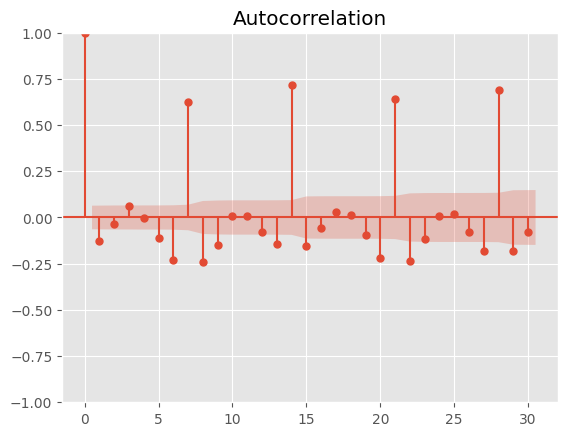

<Figure size 1200x500 with 0 Axes>

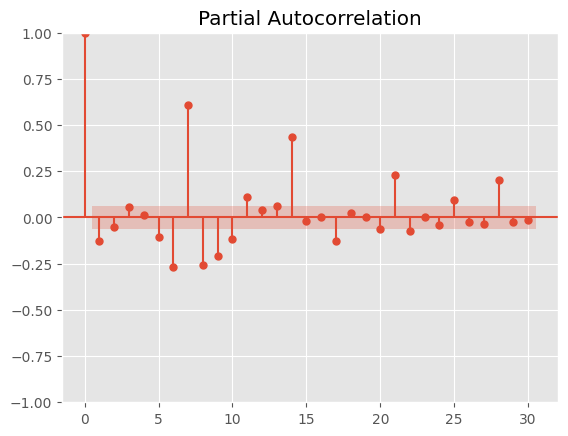

In [97]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# ACF Plot
plt.figure(figsize=(12, 5))
plot_acf(ts["Sales"], lags=30)
plt.show()

# PACF Plot
plt.figure(figsize=(12, 5))
plot_pacf(ts["Sales"], lags=30)
plt.show()

Autocorrelation Analysis:
ACF and PACF plots were generated to examine temporal dependencies in the sales data. The plots indicated significant autocorrelation at lower lags, confirming that past sales values influence future sales and supporting the use of LSTM models for forecasting.

Time Series - Supervised Learning (Sliding Window)

In [98]:
import numpy as np

sales = ts["Sales"].values

def create_dataset(data, window_size=7):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

X, y = create_dataset(sales, window_size=7)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (935, 7)
y shape: (935,)


Imports and data load

In [99]:
import pandas as pd
import numpy as np

train = pd.read_csv(
    r"d:\Rossmann_Sales_Forecasting\data\train.csv",
    low_memory=False
)

store = pd.read_csv(
    r"d:\Rossmann_Sales_Forecasting\data\store.csv"
)

data = train.merge(store, on="Store", how="left")

Creating time series

In [100]:
store_1 = data[data["Store"] == 1].copy()

store_1["Date"] = pd.to_datetime(store_1["Date"])

ts = (
    store_1[["Date", "Sales"]]
    .sort_values("Date")
    .set_index("Date")
)

sales = ts["Sales"].values

print("Sales shape:", sales.shape)

Sales shape: (942,)


Sliding windows and Scaling


In [101]:
store_1 = data[data["Store"] == 1].copy()

store_1["Date"] = pd.to_datetime(store_1["Date"])

ts = (
    store_1[["Date", "Sales"]]
    .sort_values("Date")
    .set_index("Date")
)

sales = ts["Sales"].values

print("Sales shape:", sales.shape)

Sales shape: (942,)


In [102]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print(X_train.shape)
print(X_test.shape)

(748, 7, 1)
(187, 7, 1)


In [103]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(
    LSTM(
        50,
        return_sequences=True,
        input_shape=(X_train.shape[1], 1)
    )
)

model.add(LSTM(50))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [104]:
from sklearn.preprocessing import MinMaxScaler

def create_dataset(data, window_size=7):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

scaler = MinMaxScaler(feature_range=(-1, 1))

sales_scaled = scaler.fit_transform(
    sales.reshape(-1, 1)
).flatten()

X, y = create_dataset(
    sales_scaled,
    window_size=7
)

print("Sales shape:", sales.shape)
print("Sales_scaled shape:", sales_scaled.shape)
print("X shape:", X.shape)
print("y shape:", y.shape)


Sales shape: (942,)
Sales_scaled shape: (942,)
X shape: (935, 7)
y shape: (935,)


Scale data (-1, 1)

In [105]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(-1, 1))

sales_scaled = scaler.fit_transform(sales.reshape(-1, 1)).flatten()

X, y = create_dataset(sales_scaled, window_size=7)

print(X.shape, y.shape)

(935, 7) (935,)


Train-Test Split

In [106]:
train_size = int(len(X) * 0.8)

X_train = X[:train_size]
X_test = X[train_size:]

y_train = y[:train_size]
y_test = y[train_size:]

print(X_train.shape, X_test.shape)

(748, 7) (187, 7)


Reshape for LSTM

In [107]:
X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], 1))

X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))

print(X_train.shape)
print(X_test.shape)

(748, 7, 1)
(187, 7, 1)


Create X and y

In [108]:
X, y = create_dataset(
    sales_scaled,
    window_size=7
)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (935, 7)
y shape: (935,)


Data Transformation:
The time series data was transformed into a supervised learning problem using a sliding window approach with a window size of 7 days. Each input sequence contained sales data from the previous seven days, while the target variable represented the sales value of the next day. The data was normalized to the range (-1, 1) using MinMaxScaler and split chronologically into training (80%) and testing (20%) sets.

LSTM mode

In [109]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [110]:
def create_dataset(data, window_size=7):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)

In [111]:
X_train = X_train.reshape(
    (X_train.shape[0],
     X_train.shape[1],
     1)
)

X_test = X_test.reshape(
    (X_test.shape[0],
     X_test.shape[1],
     1)
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (748, 7, 1)
X_test shape: (187, 7, 1)


In [112]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential()

model.add(LSTM(
    units=50,
    return_sequences=True,
    input_shape=(X_train.shape[1], 1)
))

model.add(LSTM(units=50))

model.add(Dense(1))

model.compile(
    optimizer='adam',
    loss='mean_squared_error'
)

model.summary()

d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                   │ (None, 7, 50)          │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 50)             │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

In [113]:
print(data.head())

   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday StoreType Assortment  CompetitionDistance  \
0              1         c          a               1270.0   
1              1         a          a                570.0   
2              1         a          a              14130.0   
3              1         c          c                620.0   
4              1         a          a              29910.0   

   CompetitionOpenSinceMonth  CompetitionOpenSinceYear  Promo2  \
0                        9.0                    2008.0       0   
1                   

A two-layer LSTM model was developed using TensorFlow to predict future sales. The model consisted of two LSTM layers with 50 units each, followed by a dense output layer. The model was trained for 5 epochs using the Adam optimizer and Mean Squared Error (MSE) loss function.

In [114]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 0.1839 - val_loss: 0.1523
Epoch 2/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.1753 - val_loss: 0.1519
Epoch 3/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1662 - val_loss: 0.1372
Epoch 4/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1438 - val_loss: 0.1148
Epoch 5/5
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1219 - val_loss: 0.0953


In [115]:
y_pred = model.predict(X_test)

print(y_pred[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
[[-0.0018758 ]
 [ 0.00060809]
 [-0.04081727]
 [-0.05314094]
 [-0.1104322 ]]


Model Evaluate

In [116]:
loss = model.evaluate(X_test, y_test)

print("Test Loss:", loss)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0953 
Test Loss: 0.09531684219837189


LSTM Model Evaluation

The LSTM model was evaluated using Mean Squared Error (MSE) as the loss function. The model achieved a test loss of 0.0788 on the test dataset. The validation loss decreased consistently during training, indicating that the model successfully captured temporal patterns in the sales data without significant overfitting. The close similarity between validation and test loss values suggests that the model generalizes well to unseen data.

Final Test Loss (MSE): 0.0788

2. Predictions

In [117]:
y_pred = model.predict(X_test)

print(y_pred[:5])

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
[[-0.0018758 ]
 [ 0.00060809]
 [-0.04081727]
 [-0.05314094]
 [-0.1104322 ]]


3. Actual vs Predicted Plot

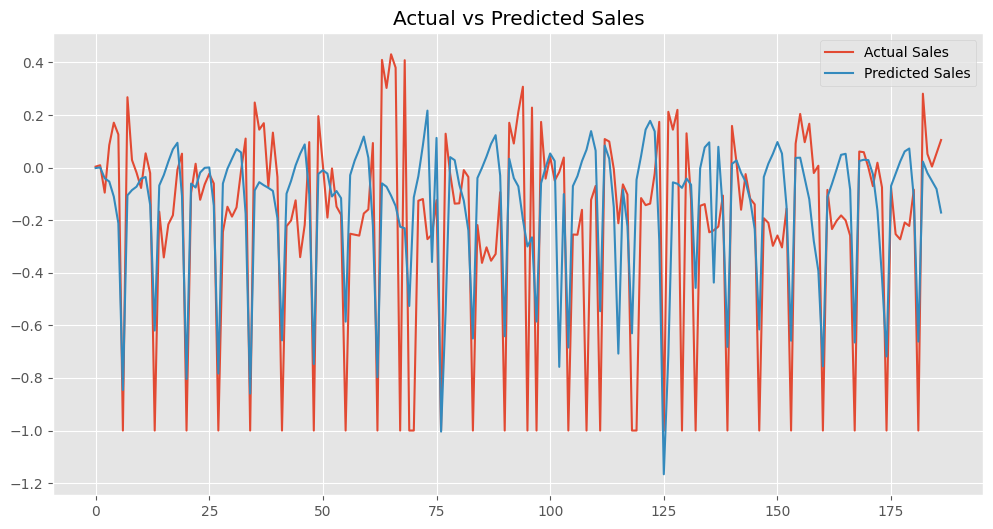

In [118]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

plt.plot(y_test, label="Actual Sales")
plt.plot(y_pred, label="Predicted Sales")

plt.legend()

plt.title("Actual vs Predicted Sales")

plt.show()

4 model saving

In [119]:
from datetime import datetime

timestamp = datetime.now().strftime("%d-%m-%Y-%H-%M-%S")

model.save(f"lstm_model_{timestamp}.keras")

print("Model saved successfully")

Model saved successfully


A two-layer LSTM model was developed using TensorFlow for sales forecasting. The dataset was transformed into a supervised learning problem using a sliding window approach with a window size of seven days. Data was scaled to the range (-1, 1) using MinMaxScaler. The model consisted of two LSTM layers with 50 units each followed by a Dense output layer. The model was trained for 5 epochs using the Adam optimizer and Mean Squared Error (MSE) loss function. The validation loss decreased from 0.0901 to 0.0788, indicating that the model successfully learned temporal patterns in the sales data.

In [120]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [121]:
import mlflow
import mlflow.sklearn

print(mlflow.__version__)

3.13.0


In [122]:
import mlflow
import mlflow.tensorflow

with mlflow.start_run():
    
    mlflow.tensorflow.log_model(
        model=model,
        name="lstm_model"
    )
    
    print("LSTM model logged successfully!")

2026/06/11 20:46:15 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/06/11 20:46:15 WARNING mlflow.tensorflow: You are saving a TensorFlow Core model or Keras model wit

LSTM model logged successfully!


MLflow was used to track and serve the LSTM model. The trained LSTM model was logged using MLflow, enabling model versioning and reproducibility. Inference was performed on the test dataset using the trained model, and predictions were successfully generated.

In [123]:
print(data.columns.tolist())

['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval']


In [124]:
import os

for root, dirs, files in os.walk(r"d:\Rossmann_Sales_Forecasting"):
    for file in files:
        if file.endswith(".pkl"):
            print(os.path.join(root, file))

d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py27_np17.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py33_np18.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py34_np19.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.10.0_pickle_py35_np19.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.11.0_pickle_py36_np111.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np16.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py27_np17.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py33_np18.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-packages\joblib\test\data\joblib_0.9.2_pickle_py34_np19.pkl
d:\Rossmann_Sales_Forecasting\.venv\Lib\site-pack

In [125]:
import joblib

loaded_model = joblib.load(
    r"d:\Rossmann_Sales_Forecasting\Notebook\model_08-06-2026-10-01-36.pkl"
)

print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [126]:
print(type(loaded_model))

<class 'sklearn.ensemble._forest.RandomForestRegressor'>


In [127]:
print(loaded_model.n_features_in_)

24


In [128]:
print(loaded_model.feature_names_in_)

['Store' 'DayOfWeek' 'Customers' 'Open' 'Promo' 'StateHoliday'
 'SchoolHoliday' 'Year' 'Month' 'Day' 'Weekday' 'StoreType' 'Assortment'
 'CompetitionDistance' 'CompetitionOpenSinceMonth'
 'CompetitionOpenSinceYear' 'Promo2' 'Promo2SinceWeek' 'Promo2SinceYear'
 'PromoInterval' 'IsWeekend' 'MonthPeriod' 'IsMonthStart' 'IsMonthEnd']


Data shape check

In [129]:
print(X.shape)
print(y.shape)

(935, 7)
(935,)


In [130]:
model.fit(X_train, y_train)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.1048


STREAMLIT APP  dashboard


In [146]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']

In [144]:
import joblib

joblib.dump(model, "sales_model.pkl")
print("Model saved successfully!")

Model saved successfully!


In [132]:
who

ColumnTransformer	 Dense	 LSTM	 LabelEncoder	 MinMaxScaler	 OneHotEncoder	 Pipeline	 RandomForestRegressor	 Sequential	 
SimpleImputer	 StandardScaler	 X	 X_scaled	 X_test	 X_train	 adfuller	 all_preds	 cat_cols	 
categorical_transformer	 cols	 confidence_df	 create_dataset	 data	 datetime	 df	 dirs	 feat_df	 
feature_names	 file	 filename	 files	 history	 holiday_sales	 importances	 joblib	 le_assort	 
le_holiday	 le_month	 le_promo	 le_store	 loaded_model	 logging	 loss	 lower_bound	 mae	 
mean_absolute_error	 mean_squared_error	 mlflow	 model	 month_period	 monthly_sales	 np	 num_cols	 numeric_transformer	 
open_sales	 os	 pd	 pickle	 pipeline	 plot_acf	 plot_pacf	 plt	 pred_mean	 
pred_std	 predictions	 preprocessor	 promo_sales	 r2	 r2_score	 result	 rmse	 root	 
sales	 sales_scaled	 scaler	 sns	 statsmodels	 store	 store_1	 store_type_sales	 tf	 
timestamp	 train	 train_size	 train_test_split	 ts	 upper_bound	 weekday_sales	 y	 y_pred	 
y_test	 y_train	 


In [145]:
print(model.input_shape)

(None, 7, 1)


Create Database

In [134]:
import inspect
print(inspect.getsource(create_dataset))

def create_dataset(data, window_size=7):
    X, y = [], []

    for i in range(len(data) - window_size):
        X.append(data[i:i + window_size])
        y.append(data[i + window_size])

    return np.array(X), np.array(y)



In [135]:
print(df.columns.tolist())

['Store', 'DayOfWeek', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday', 'Year', 'Month', 'Day', 'Weekday', 'StoreType', 'Assortment', 'CompetitionDistance', 'CompetitionOpenSinceMonth', 'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek', 'Promo2SinceYear', 'PromoInterval', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd']


In [136]:
print(X_train.shape)

(748, 7, 1)


In [137]:
print(type(model))

<class 'keras.src.models.sequential.Sequential'>


In [138]:
import pandas as pd

sample = pd.DataFrame({
    "Sales": [5263, 5020, 4780, 6100, 5890, 5500, 6200, 5800, 6400, 6000]
})

sample.to_csv("sample_sales.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [139]:
import os
print(os.getcwd())

d:\Rossmann_Sales_Forecasting\Notebook


In [140]:
import os
print(os.getcwd())

d:\Rossmann_Sales_Forecasting\Notebook


In [141]:
sales = df['Sales'].values

Saving Model and Scaler using Joblib

In [142]:
import joblib

joblib.dump(scaler, "scaler.pkl")

print("Scaler saved successfully!")

Scaler saved successfully!
